In [35]:
import xarray as xr
import matplotlib.pyplot as plt
from src.shash_torch import Shash
import numpy as np
import torch
from sklearn.model_selection import KFold
from src.shash_torch import Shash
from src.loss import ShashNLL
from pathlib import Path


In [47]:
model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
model_spec = 'cnn3d_3_layer/level=small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'

In [37]:
results = xr.open_dataset(f'results/predictions/{model_spec}/predictions.nc')

In [38]:
def fit_shash(train_truth: xr.DataArray,
              steps=2000,
              lr=1e-2):

    x_train = torch.tensor(train_truth.values, dtype=torch.float32)

    B, K = x_train.shape

    params = torch.nn.Parameter(torch.zeros(K,4))

    params.data[:,0] = x_train.mean(dim=0)
    params.data[:,1] = torch.log(x_train.std(dim=0)+1e-3)
    params.data[:,2] = 0.0
    params.data[:,3] = 0.0

    optimizer = torch.optim.Adam([params], lr=lr)
    loss_fn = ShashNLL(reduction="mean")

    for _ in range(steps):
        optimizer.zero_grad()

        outputs = params.unsqueeze(0).expand(B,-1,-1).reshape(B,4*K)
        loss = loss_fn(outputs, x_train)

        loss.backward()
        optimizer.step()

    return params.detach()

In [39]:
T = results.dims["time"]
K = results.dims["target"]

nll_pred = torch.zeros(T, K)
nll_baseline = torch.zeros(T, K)
llr_vals = torch.zeros(T, K)
kl_vals = torch.zeros(T, K)
N = 1000   # MC samples

In [40]:
truth = torch.tensor(results["truth"].values, dtype=torch.float32)

pred_params = torch.stack([
    torch.tensor(results["mu"].values),
    torch.log(torch.tensor(results["sigma"].values)),
    torch.tensor(results["gamma"].values),
    torch.log(torch.tensor(results["tau"].values))
], dim=-1)  # (time, target, 4)

pred_outputs = pred_params.reshape(T, 4*K)

In [41]:
loss_fn_none = ShashNLL(reduction="none")

nll_pred[:] = loss_fn_none(pred_outputs, truth)

In [42]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)
for fold, (train_idx, val_idx) in enumerate(kf.split(results["time"])):

    train_ds = results.isel(time=train_idx)
    val_ds = results.isel(time=val_idx)

    baseline_params = fit_shash(train_ds["truth"])  # (K,4)

    Bv = len(val_idx)

    baseline_outputs = (
        baseline_params.unsqueeze(0)
        .expand(Bv,-1,-1)
        .reshape(Bv,4*K)
    )

    x_val = torch.tensor(val_ds["truth"].values, dtype=torch.float32)

    # baseline NLL
    nll_baseline[val_idx] = loss_fn_none(baseline_outputs, x_val)

    # predicted outputs
    pred_fold = pred_outputs[val_idx]

    # log likelihood ratio
    llr_vals[val_idx] = (
        loss_fn_none(baseline_outputs, x_val)
        - loss_fn_none(pred_fold, x_val)
    )

    # ----- TRUE KL divergence -----

    pred_params_fold = pred_fold.reshape(Bv, K, 4)
    base_params_fold = baseline_params.unsqueeze(0).expand(Bv, -1, -1)

    # draw samples
    eps = torch.randn(N, Bv, K)

    mu_p = pred_params_fold[...,0]
    sigma_p = torch.exp(pred_params_fold[...,1])
    gamma_p = pred_params_fold[...,2]
    tau_p = torch.exp(pred_params_fold[...,3])

    z = torch.sinh((torch.asinh(eps) + gamma_p) / tau_p)
    samples = mu_p + sigma_p * z          # (N,Bv,K)

    # reshape to match ShashNLL input
    samples_flat = samples.reshape(N*Bv, K)

    pred_out = pred_params_fold.reshape(Bv,4*K).repeat(N,1)
    base_out = base_params_fold.reshape(Bv,4*K).repeat(N,1)

    # log probabilities via negative NLL
    logp_pred = -loss_fn_none(pred_out, samples_flat)
    logp_base = -loss_fn_none(base_out, samples_flat)

    # reshape back
    logp_pred = logp_pred.reshape(N,Bv,K)
    logp_base = logp_base.reshape(N,Bv,K)

    kl_vals[val_idx] = (logp_pred - logp_base).mean(dim=0)

In [43]:
results["nll_pred"] = (("time","target"), nll_pred.numpy())
results["nll_baseline"] = (("time","target"), nll_baseline.numpy())
results["llr_vals"] = (("time","target"), llr_vals.numpy())
results["kl_vals"] = (("time","target"), kl_vals.numpy())

In [44]:
Path(f'results/predictions_losses/{model_spec}').mkdir(parents=True, exist_ok=True)
results.to_netcdf(f'results/predictions_losses/{model_spec}/predictions.nc')

Analysis

In [48]:
results = xr.open_dataset(f'results/predictions_losses/{model_spec}/predictions.nc')

In [51]:
results

<xarray.Dataset>
Dimensions:       (time: 332, target: 9)
Coordinates:
  * time          (time) datetime64[ns] 2002-04-07 2002-04-13 ... 2019-05-20
  * target        (target) int64 0 1 2 3 4 5 6 7 8
Data variables:
    mu            (time, target) float32 0.2403 -0.04291 ... -0.4798 0.1382
    sigma         (time, target) float32 0.92 1.088 0.7807 ... 0.743 1.311 1.006
    gamma         (time, target) float32 -0.06752 0.0188 ... 0.02209 -0.2036
    tau           (time, target) float32 1.348 0.9453 0.9571 ... 1.183 1.266
    truth         (time, target) float32 -0.4253 2.106 1.038 ... 1.401 0.9207
    nll_pred      (time, target) float32 0.8725 2.71 1.412 ... 2.473 1.319
    nll_baseline  (time, target) float32 1.083 3.336 1.762 ... 2.004 1.488
    llr_vals      (time, target) float32 0.2107 0.6266 0.3501 ... -0.4688 0.1692
    kl_vals       (time, target) float32 0.1494 0.03455 ... 0.1235 0.09965

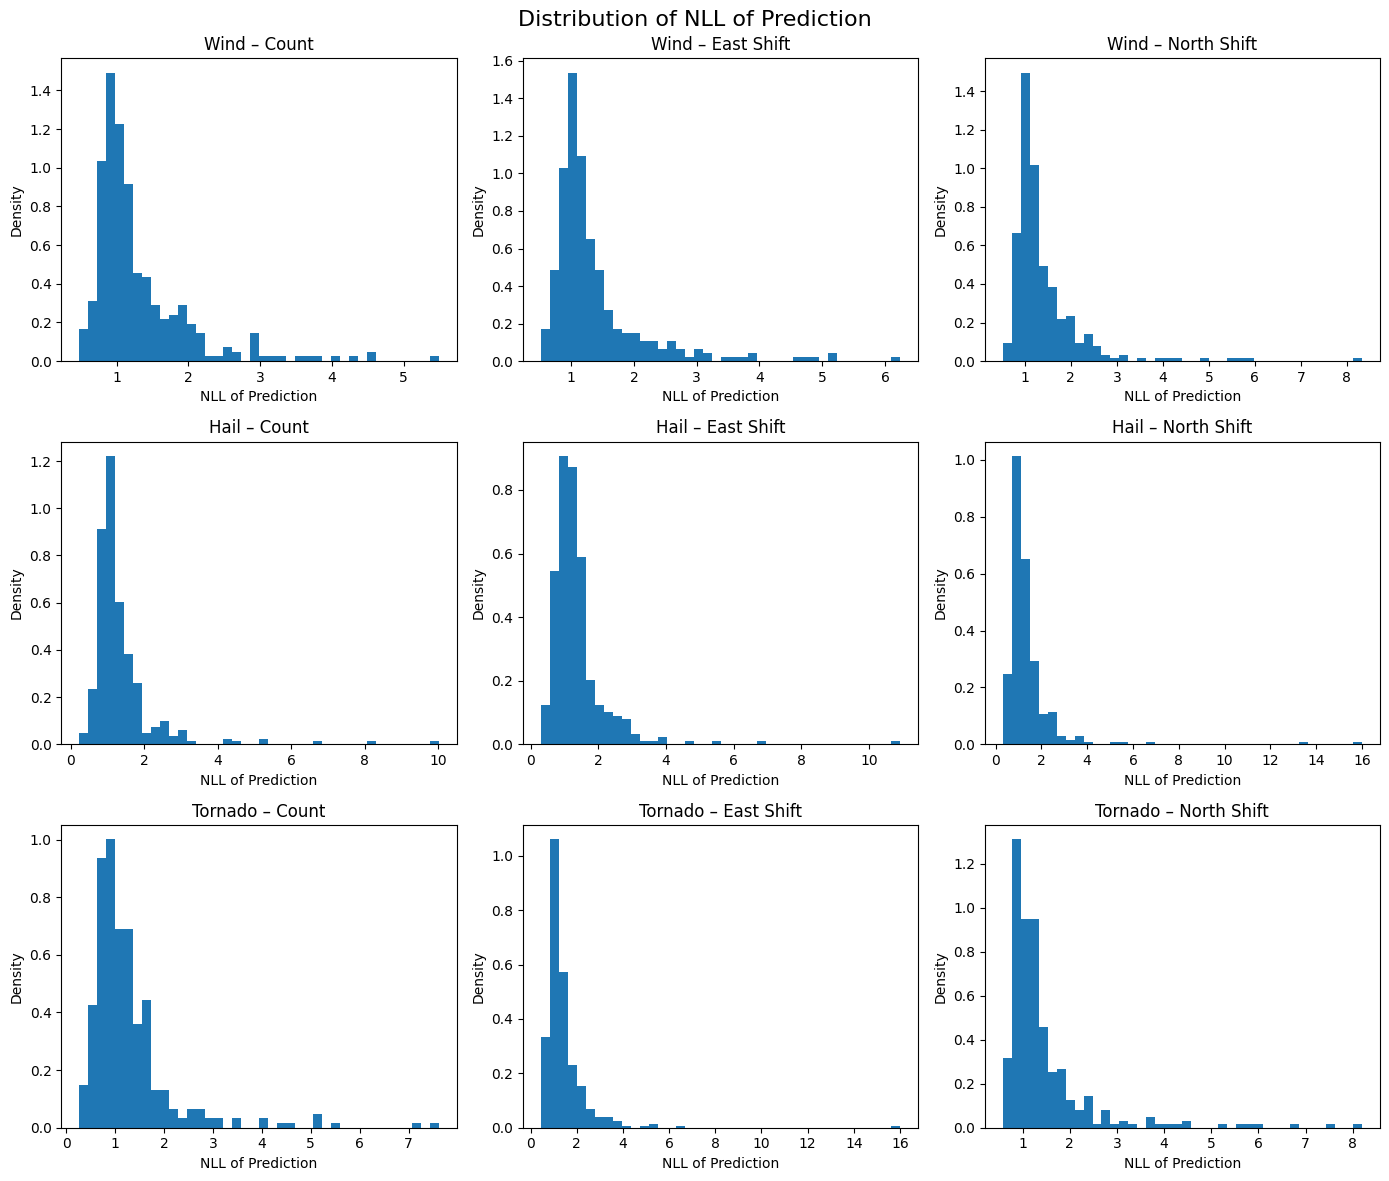

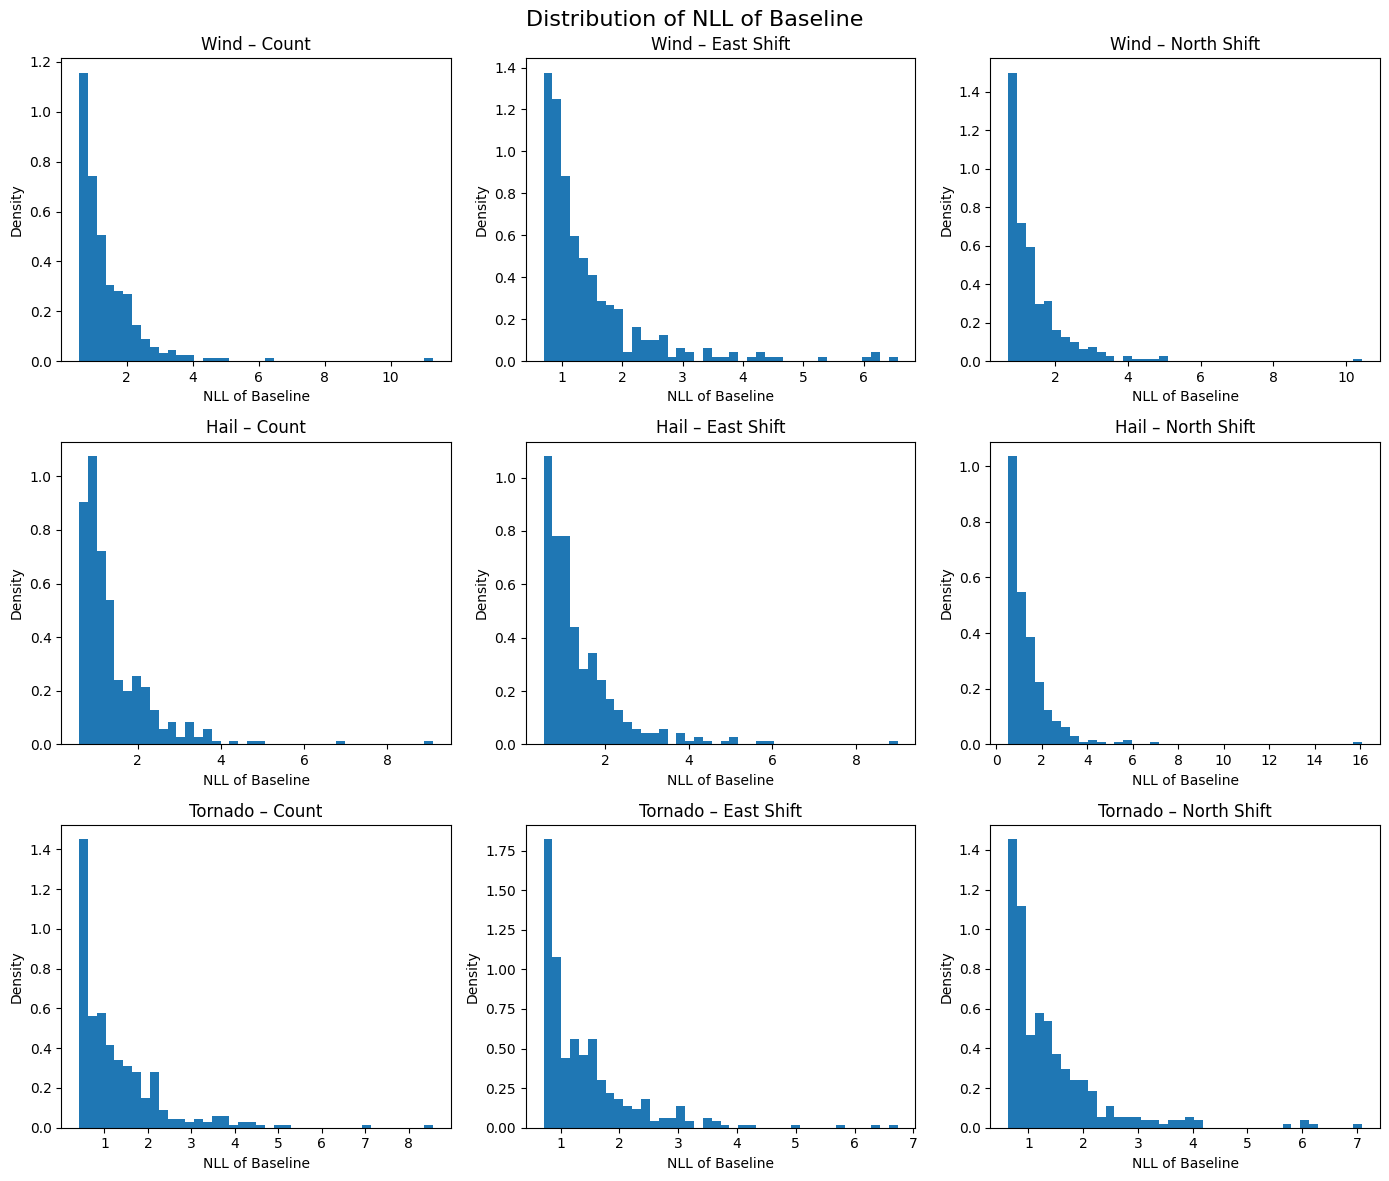

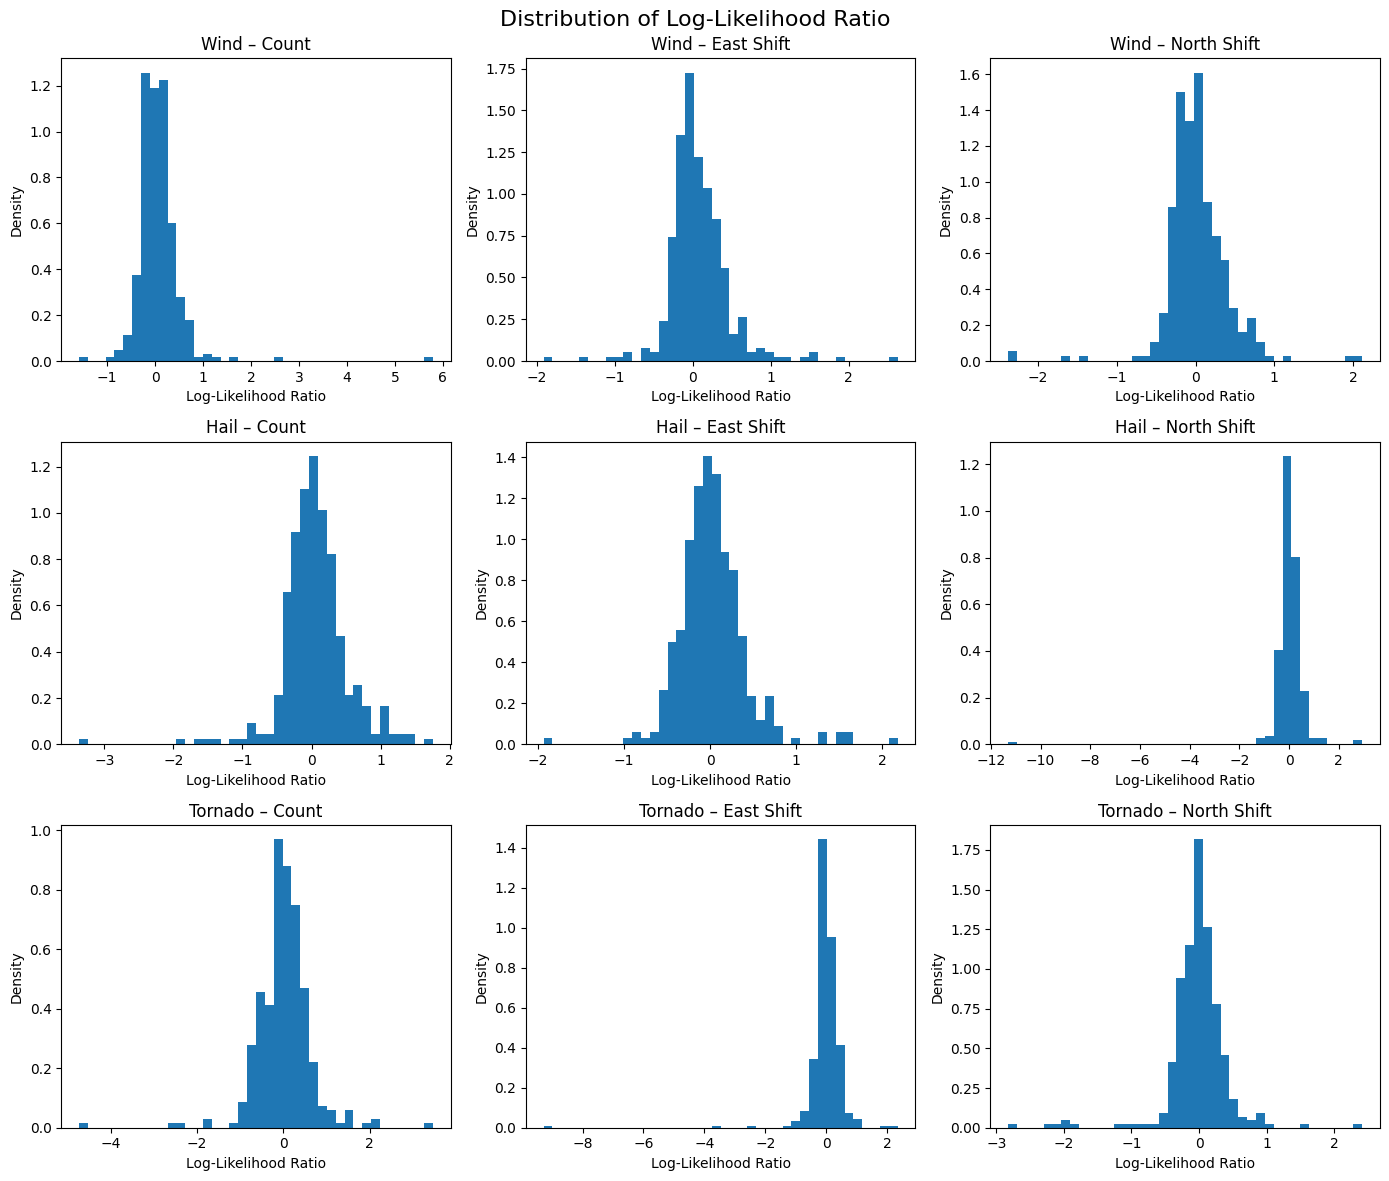

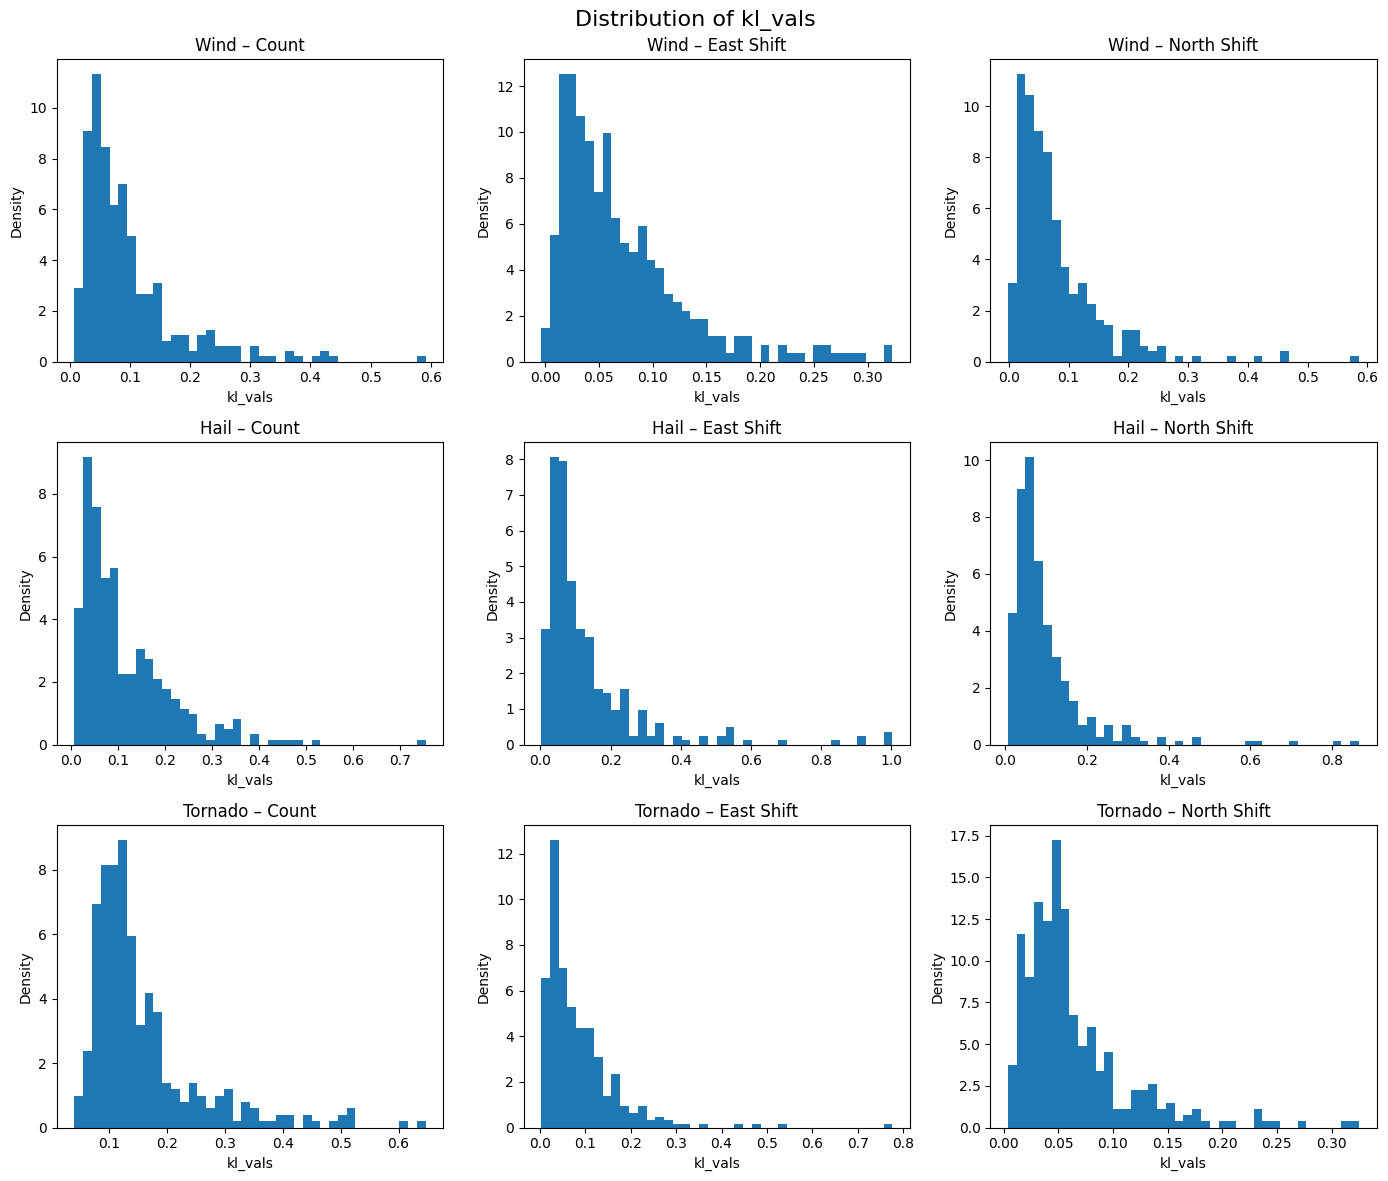

In [52]:
hazards = ["Wind", "Hail", "Tornado"]
variables = ["Count", "East Shift", "North Shift"]

nll_pred = results["nll_pred"].values
nll_baseline = results["nll_baseline"].values
llr_vals = results["llr_vals"].values
kl_vals = results["kl_vals"].values

param_dict = {
    "NLL of Prediction": nll_pred,
    "NLL of Baseline": nll_baseline,
    "Log-Likelihood Ratio": llr_vals,
    "kl_vals": kl_vals
}

for param_name, values in param_dict.items():
    
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)
    
    for i, hazard in enumerate(hazards):
        for j, var in enumerate(variables):
            k = i * 3 + j  # flattened index
            bins = 40
            ax = axes[i, j]
            
            ax.hist(values[:, k], bins=bins, density=True)
            
            ax.set_title(f"{hazard} – {var}")
            ax.set_xlabel(param_name)
            ax.set_ylabel("Density")
    
    fig.suptitle(f"Distribution of {param_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

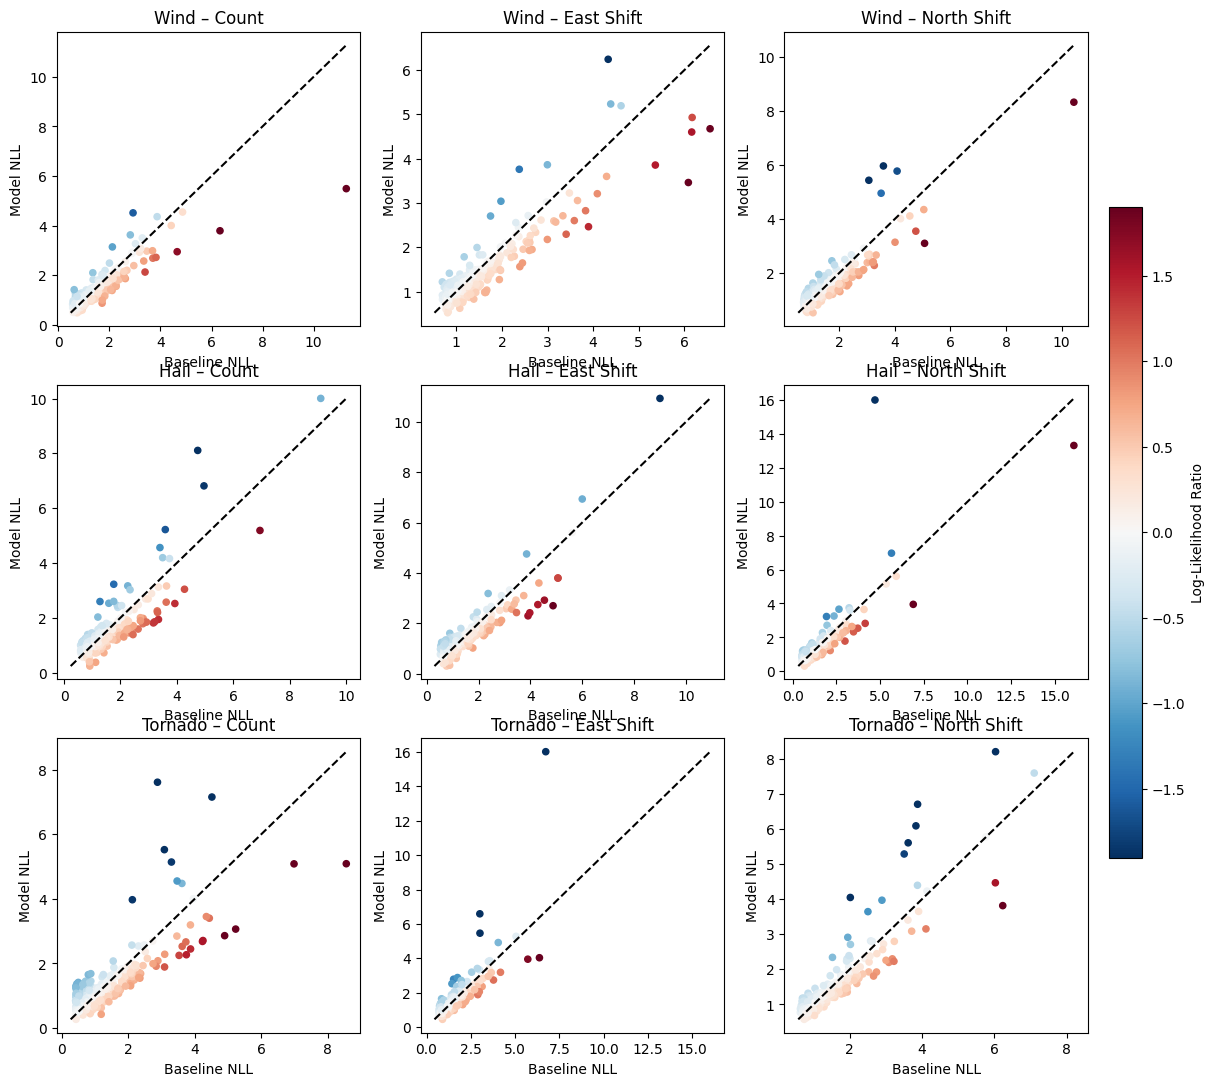

In [65]:
from matplotlib.colors import TwoSlopeNorm

p = np.percentile(np.abs(llr_vals), 99)
norm = TwoSlopeNorm(vmin=-p, vcenter=0, vmax=p)

fig, axes = plt.subplots(3,3, figsize=(14,13))

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):

        k = i*3 + j
        ax = axes[i,j]

        x = nll_baseline[:,k]
        y = nll_pred[:,k]
        c = llr_vals[:,k]

        sc = ax.scatter(
            x, y,
            c=c,
            cmap="RdBu_r",
            norm=norm,
            s=20
        )

        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo,hi],[lo,hi],'k--')

        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Baseline NLL")
        ax.set_ylabel("Model NLL")

fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.03, pad=0.02, label="Log-Likelihood Ratio")
#plt.tight_layout()
plt.show()

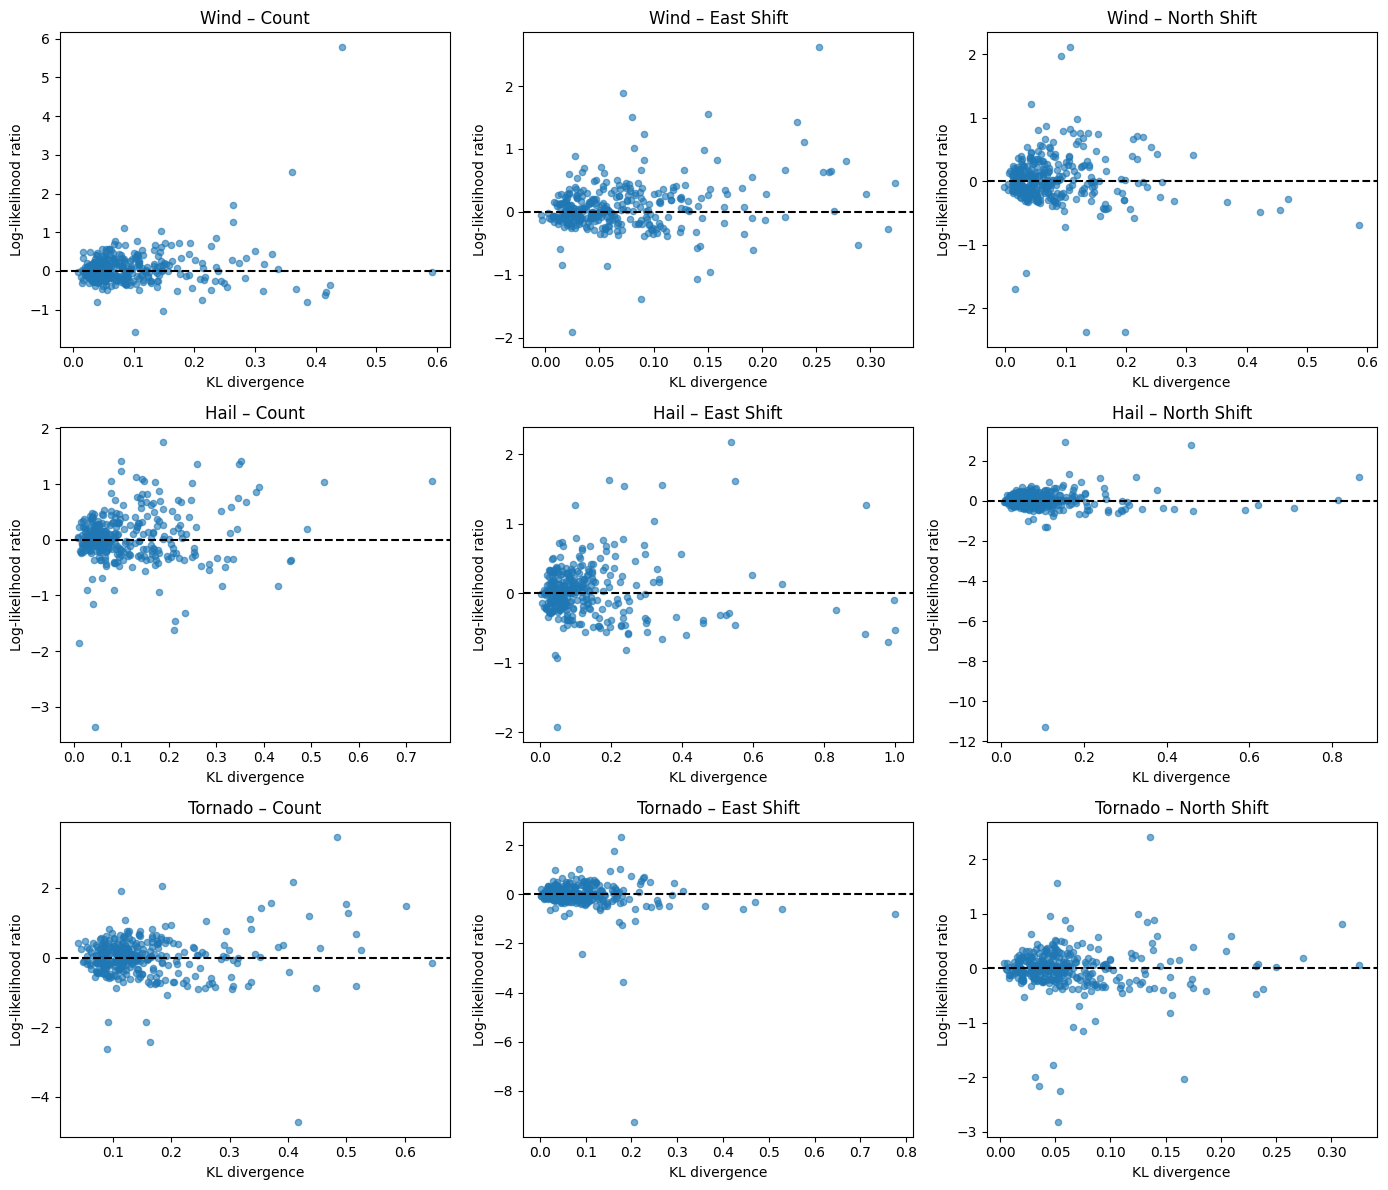

In [54]:
fig, axes = plt.subplots(3,3, figsize=(14,12))

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):

        k = i*3 + j
        ax = axes[i,j]

        ax.scatter(kl_vals[:,k], llr_vals[:,k], s=20, alpha=0.6)

        ax.axhline(0, color='k', ls='--')

        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("KL divergence")
        ax.set_ylabel("Log-likelihood ratio")

plt.tight_layout()
plt.show()

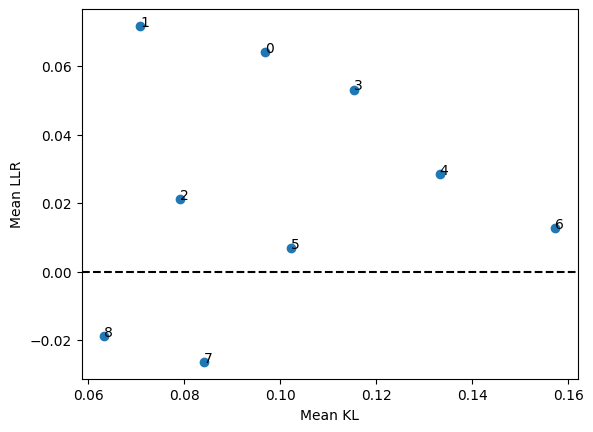

In [66]:
mean_llr = llr_vals.mean(axis=0)
mean_kl = kl_vals.mean(axis=0)

plt.scatter(mean_kl, mean_llr)

for k in range(9):
    plt.text(mean_kl[k], mean_llr[k], str(k))

plt.xlabel("Mean KL")
plt.ylabel("Mean LLR")
plt.axhline(0,color='k',ls='--')